<a href="https://colab.research.google.com/github/kessanchit2-cmd/Ml-Pracs/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#SVM
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
#load iris
iris=datasets.load_iris()
x=iris.data
y=iris.target
target_names=iris.target_names



In [8]:
#test_train_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
#model
svm=SVC(kernel='linear')
svm.fit(x_train,y_train)

SVC(kernel='linear')

In [11]:
#pred
y_ped=svm.predict(x_test)

In [12]:
#perfmance Mertics
acurraxy=accuracy_score(y_test,y_ped)
print(acurraxy)
print(classification_report(y_test,y_ped,target_names=target_names))
print(confusion_matrix(y_test,y_ped))

1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [13]:
#dimensionality reduction for visulization
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x)

In [14]:
#train svm on pca , transform data for graph
svm_vis=SVC(kernel='linear')
svm_vis.fit(x_pca,y)

SVC(kernel='linear')

In [17]:
#create an meshgrid
x_min, x_max = x_pca[:, 0].min() - 1, x_pca[:, 0].max() + 1
y_min, y_max = x_pca[:, 1].min() - 1, x_pca[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)
Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

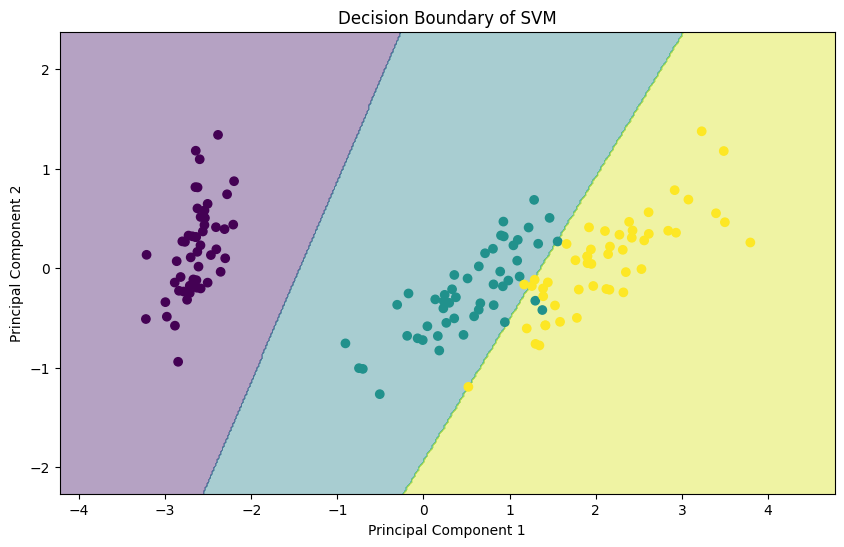

In [19]:
#plot decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Decision Boundary of SVM')
plt.show()

## Explanation of Visualization Steps

1.  **Dimensionality Reduction with PCA (`_r8f4WZ7eHNE`):**
    *   `pca = PCA(n_components=2)`: Initializes Principal Component Analysis (PCA) to reduce the data's dimensionality to 2 components. This is done to allow for 2D plotting.
    *   `x_pca = pca.fit_transform(x)`: Applies PCA to the original feature data (`x`). `fit_transform` first learns the principal components from the data and then transforms the data into the new 2-dimensional space. `x_pca` now contains the data projected onto the two most significant principal components.

2.  **Train SVM on PCA Transformed Data (`ha_B1tbceXXk`):**
    *   `svm_vis = SVC(kernel='linear')`: A new Support Vector Classifier is initialized, again using a linear kernel. This SVM will be used specifically for visualizing the decision boundary in the 2D PCA space.
    *   `svm_vis.fit(x_pca, y)`: The `svm_vis` model is trained using the 2-dimensional `x_pca` data and the original target labels `y`. This trains the SVM to classify the data based on these two principal components.

3.  **Create a Meshgrid for Decision Boundary (`1WCI3QXPehMa`):**
    *   `x_min, x_max = x_pca[:, 0].min() - 1, x_pca[:, 0].max() + 1`
    *   `y_min, y_max = x_pca[:, 1].min() - 1, x_pca[:, 1].max() + 1`: These lines determine the range for the x and y axes of our plot, extending slightly beyond the data points to ensure the entire decision boundary is captured.
    *   `xx, yy = np.meshgrid(...)`: A meshgrid is created. This generates a grid of points (`xx` and `yy`) that covers the entire plotting area. These points will be used to predict the class for every point in the visualization space.
    *   `Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])`: The `svm_vis` model predicts the class for each point in the meshgrid. `np.c_` concatenates the flattened `xx` and `yy` arrays into a 2-column array suitable for prediction.
    *   `Z = Z.reshape(xx.shape)`: The predictions `Z` are reshaped back into the original grid shape so they can be plotted as a contour.

4.  **Plot Decision Boundary (`Xt-MZp_Qe56V`):**
    *   `plt.figure(figsize=(10, 6))`: Sets up a figure for the plot with a specified size.
    *   `plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')`: This creates a filled contour plot of the decision boundary. The `Z` array, containing the class predictions for the meshgrid, is used to color regions according to the predicted class. `alpha` makes the regions semi-transparent, and `cmap` sets the color scheme.
    *   `plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y)`: The original PCA-transformed data points are plotted as a scatter plot on top of the decision boundary, with each point colored according to its actual class (`y`).
    *   `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)`: Set the labels for the axes and the title of the plot for clarity.
    *   `plt.show()`: Displays the generated plot.